In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [144]:
df = pd.read_csv(r"diabetes_prediction_dataset.csv")
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [146]:
df.duplicated().sum()

np.int64(3854)

In [147]:
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [148]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

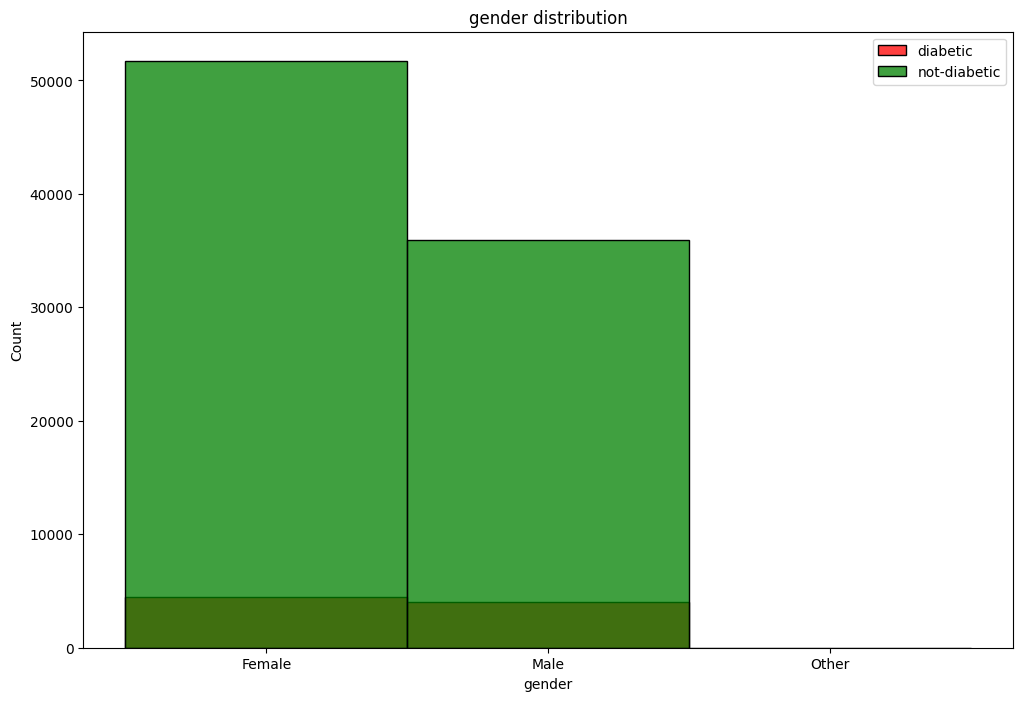

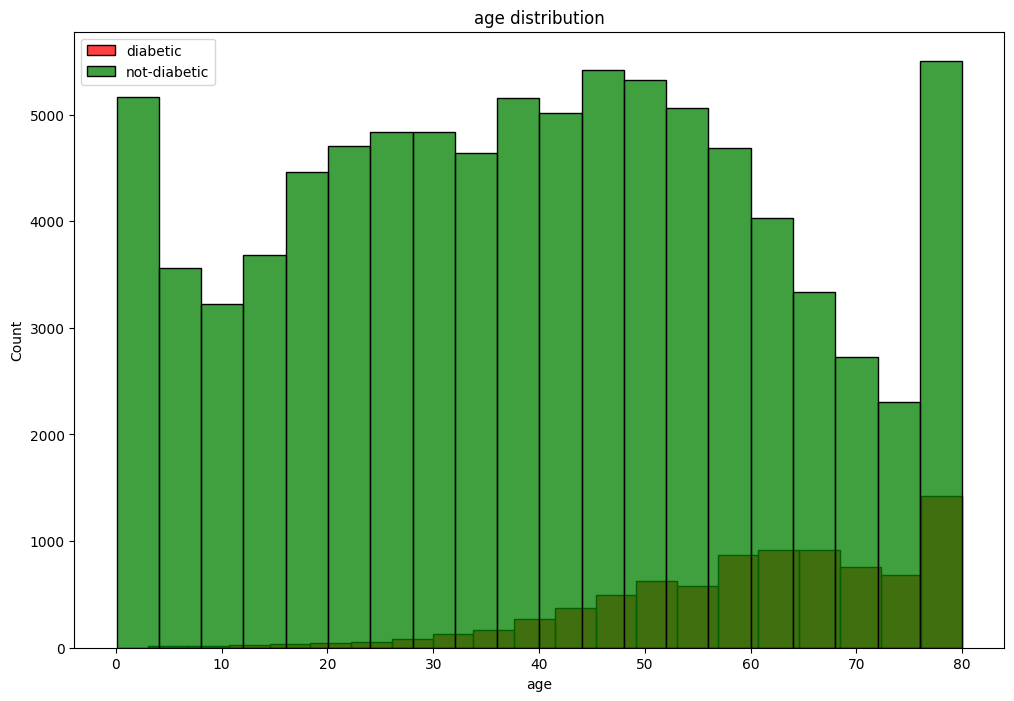

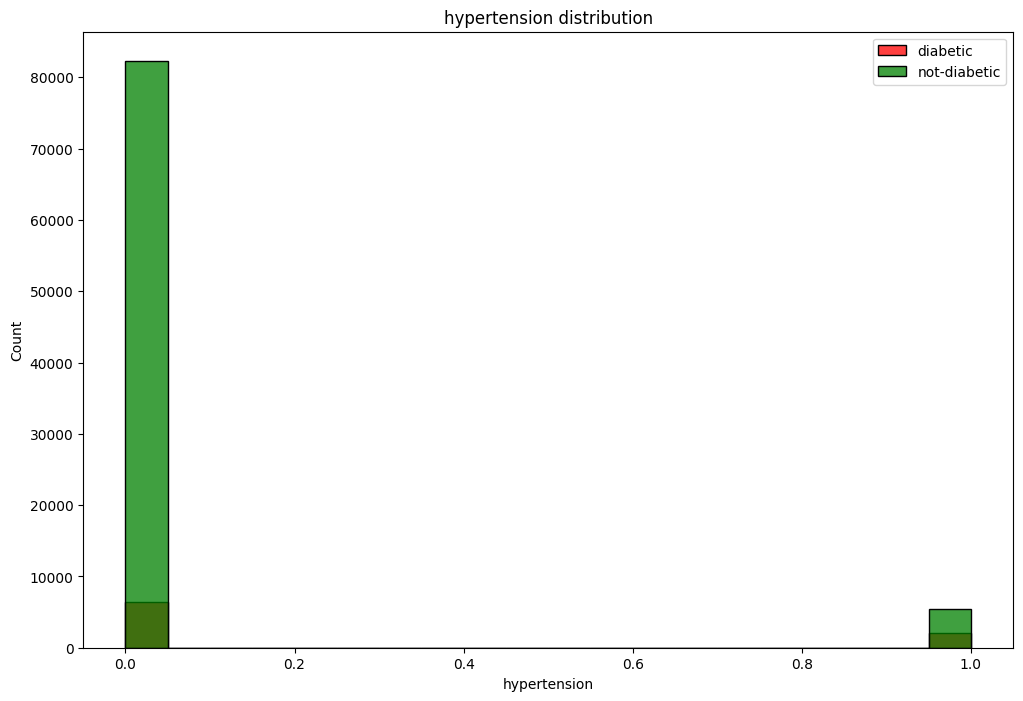

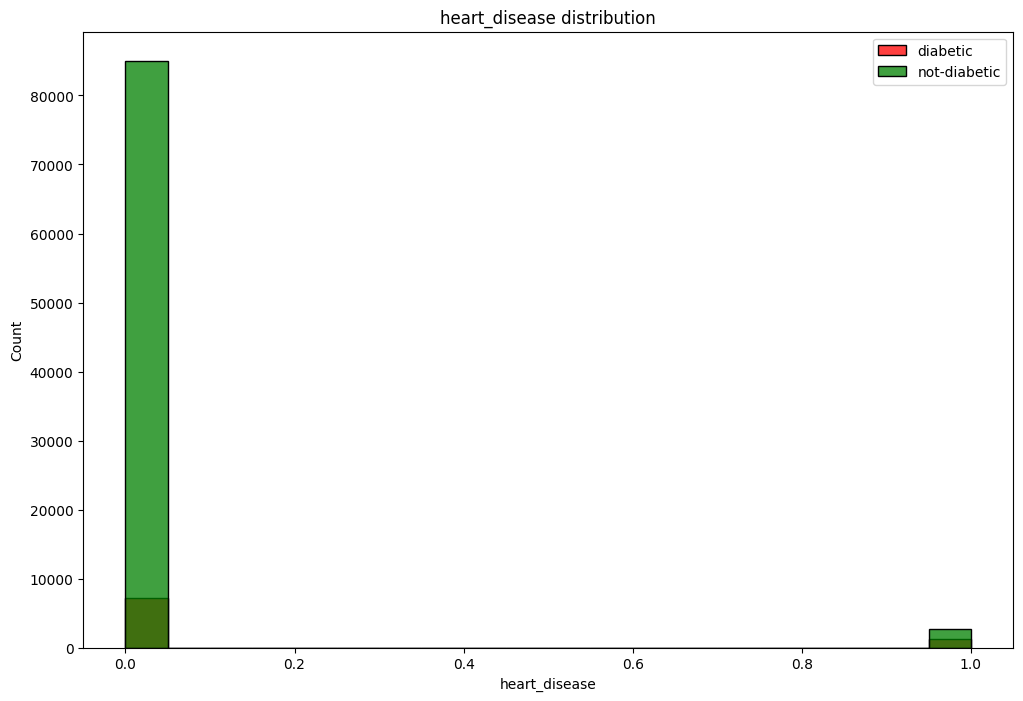

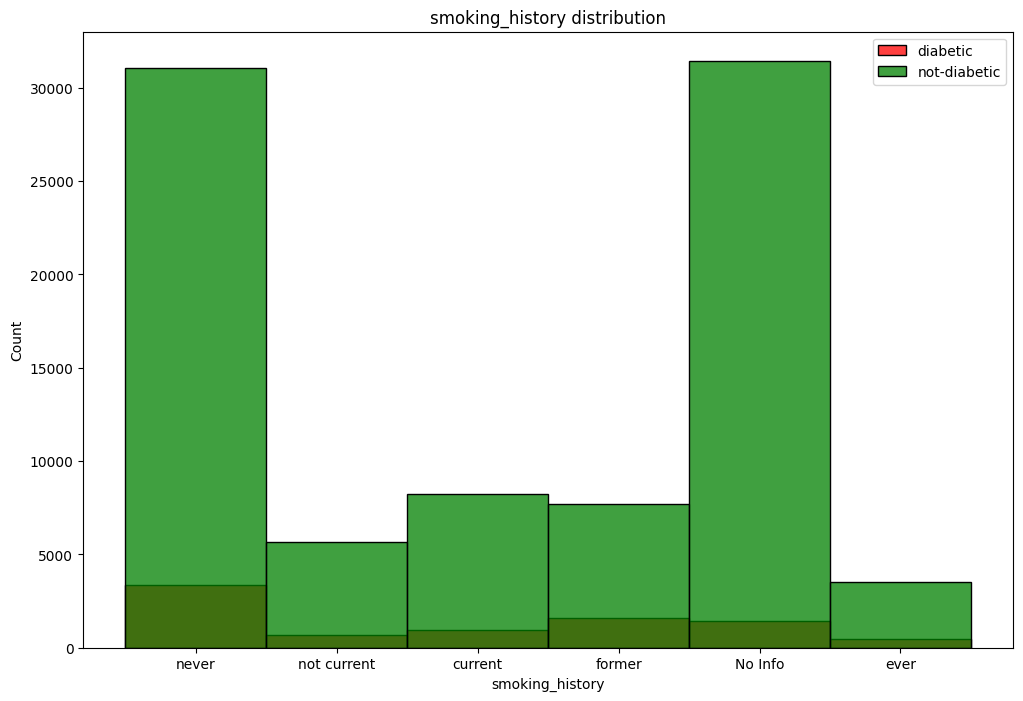

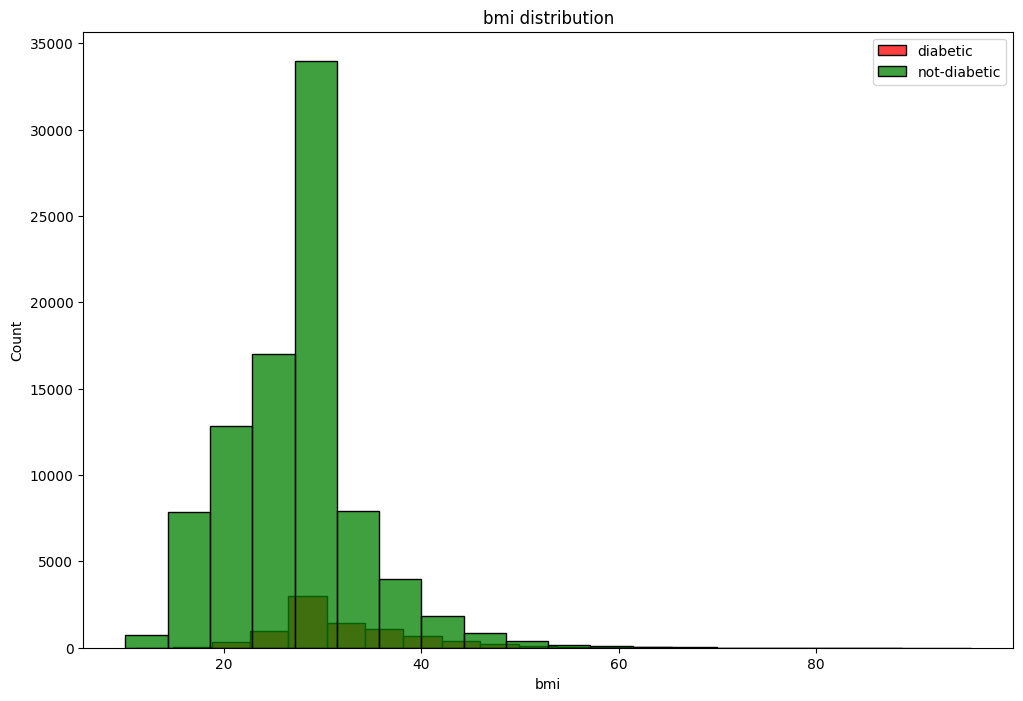

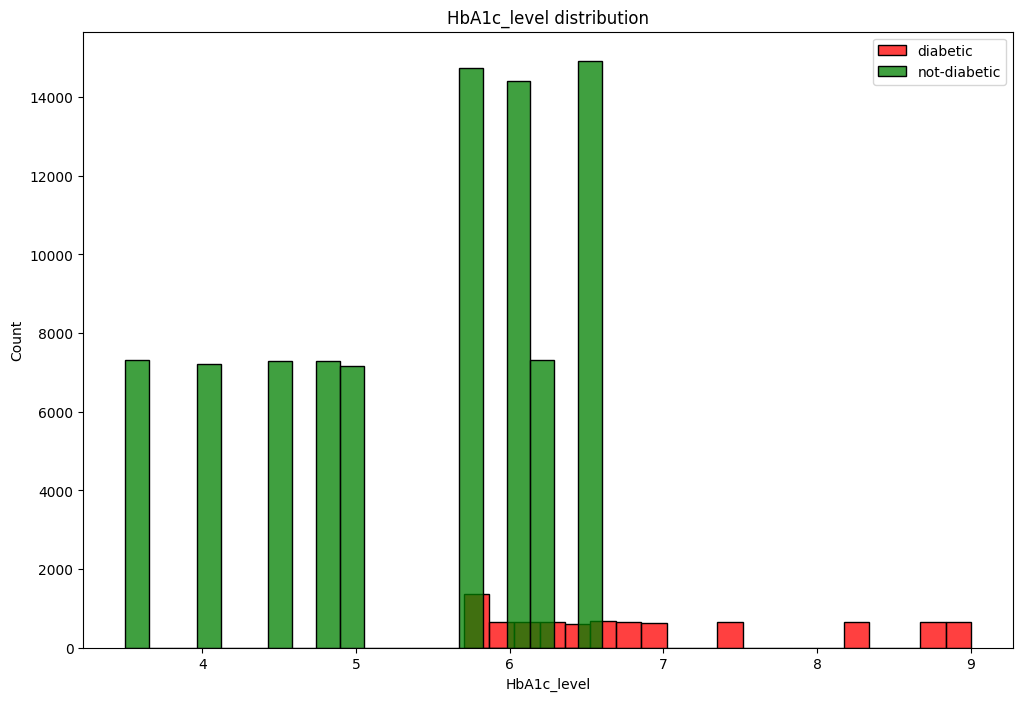

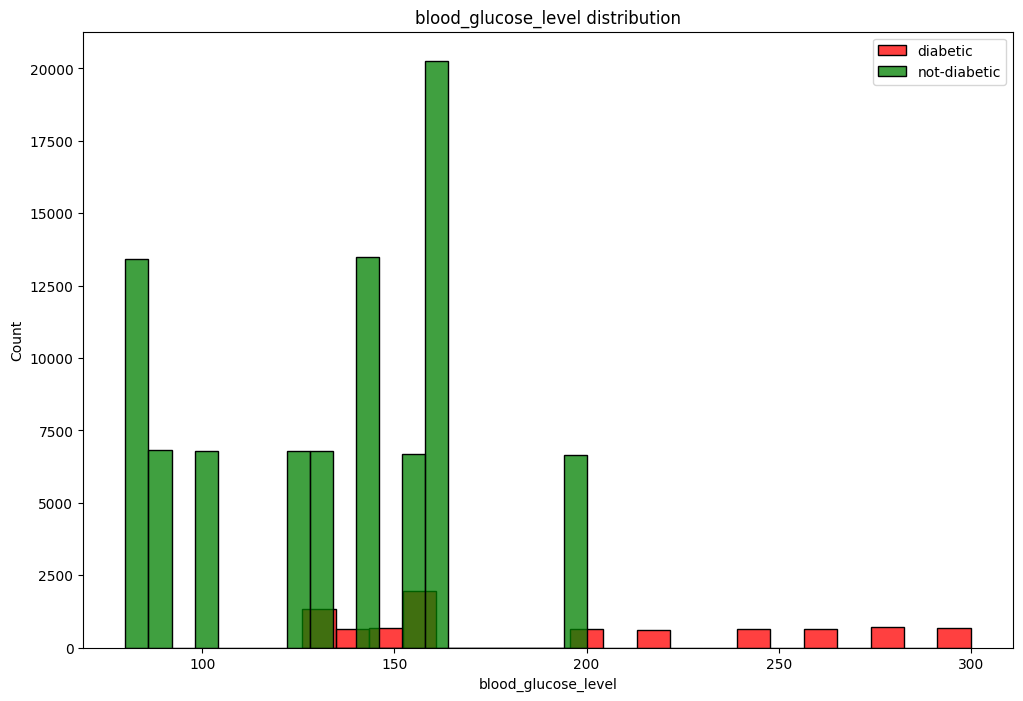

In [149]:
for col in df.columns[:-1]:
    plt.figure(figsize = (12, 8))
    sns.histplot(x = df[df["diabetes"] == 1][col],
                color = "red",
                label = "diabetic",
                edgecolor = "black",
                bins = 20)
    sns.histplot(x = df[df["diabetes"] == 0][col],
                color = "green",
                label = "not-diabetic",
                edgecolor = "black",
                bins = 20)
    plt.title(f"{col} distribution")
    plt.legend()

In [150]:
scaling_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]

def classify(model, param_config, X_train, X_test, y_train, y_test):
    preprocessor = ColumnTransformer(transformers=[
        ("ohe", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), ["smoking_history"]),
        ("ordinal", OrdinalEncoder(), ["gender"]),
        ("std", StandardScaler(), scaling_cols)
    ], remainder="passthrough")
    
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("SMOTE", SMOTE(random_state= 42)), # Oversampling to even out diabetic patients
        ("classifier", model)
    ])

    if not param_config:
        pipe.fit(X_train, y_train)
        best_pipe = pipe
        best_params_clean = {}
    else:

        search_params = {f"classifier__{key}": value for key, value in param_config["params"].items()}
        
        rand_search = RandomizedSearchCV(
            estimator= pipe,
            param_distributions= search_params,
            n_iter=param_config.get("n_iter", 10),
            cv= 5,
            scoring='f1',
            verbose= 1,
            n_jobs= -1,
            random_state= 42
        )
        rand_search.fit(X_train, y_train)
        best_pipe = rand_search.best_estimator_
        best_params_clean = {key.replace("classifier__", ""): value for key, value in rand_search.best_params_.items()}
        print(f"Best Parameters: {best_params_clean}")

    return best_pipe
        

In [151]:
X = df.drop(columns = "diabetes")
y = df["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state = 42, stratify= y)

print(X_train.shape)
print(X_test.shape)

(76916, 8)
(19230, 8)


In [152]:
lgr_model = classify(LogisticRegression(), None,
                     X_train, X_test, y_train, y_test)

rfc_model = classify(RandomForestClassifier(random_state = 42), {"method" : "Random",
                                                                             "n_iter" : 100,
                                                                             "params": {"n_estimators" : randint(100, 500),
                                                                                       "max_depth": [5, 10, 15, 20, None],
                                                                                       "min_samples_split" : randint(2, 6)}},
                                                                             X_train, X_test, y_train, y_test)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


c:\Users\medo7\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 197}


In [153]:
y_pred_lgr = lgr_model.predict(X_test)
y_proba_lgr = lgr_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lgr))
print(f"Logistic Regression ROC AUC: {roc_auc_score(y_test, y_proba_lgr)}")

print("\n===============================================================\n")


y_pred_rfc = rfc_model.predict(X_test)
y_proba_rfc = rfc_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rfc))
print(f"Random Forest Classifier ROC AUC: {roc_auc_score(y_test, y_proba_rfc)}")

              precision    recall  f1-score   support

           0       0.99      0.88      0.93     17534
           1       0.42      0.88      0.57      1696

    accuracy                           0.88     19230
   macro avg       0.71      0.88      0.75     19230
weighted avg       0.94      0.88      0.90     19230

Logistic Regression ROC AUC: 0.9600081566595144


              precision    recall  f1-score   support

           0       0.98      0.98      0.98     17534
           1       0.77      0.75      0.76      1696

    accuracy                           0.96     19230
   macro avg       0.87      0.87      0.87     19230
weighted avg       0.96      0.96      0.96     19230

Random Forest Classifier ROC AUC: 0.9690329072249924


Text(1066.1767676767674, 0.5, 'True label %')

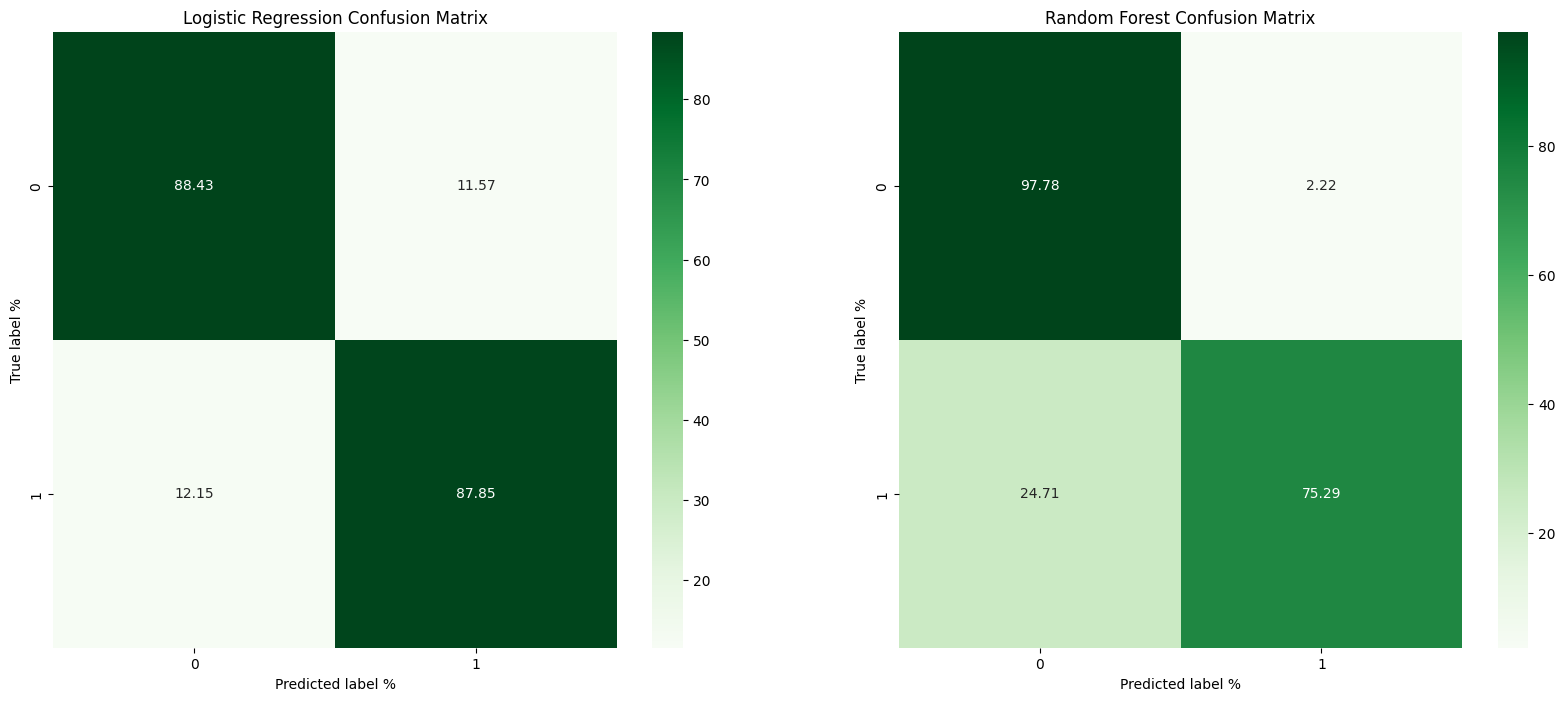

In [162]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (20, 8))

cm_lgr = confusion_matrix(y_test, y_pred_lgr)
lgr_pct = cm_lgr.astype('float') / cm_lgr.sum(axis=1)[:, np.newaxis] * 100


sns.heatmap(lgr_pct,
            annot = True,
            cmap = "Greens",
            fmt = ".2f",
            ax = ax1)
ax1.set_title("Logistic Regression Confusion Matrix")
ax1.set_xlabel("Predicted label %")
ax1.set_ylabel("True label %")

cm_rfc = confusion_matrix(y_test, y_pred_rfc)
rfc_pct = cm_rfc.astype('float') / cm_rfc.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(rfc_pct,
            annot = True,
            cmap = "Greens",
            fmt = ".2f",
            ax = ax2)
ax2.set_title("Random Forest Confusion Matrix")
ax2.set_xlabel("Predicted label %")
ax2.set_ylabel("True label %")

C:\Users\medo7\AppData\Local\Temp\ipykernel_1112\1973103241.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df_lgr, x='Importance',
C:\Users\medo7\AppData\Local\Temp\ipykernel_1112\1973103241.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df_rf,


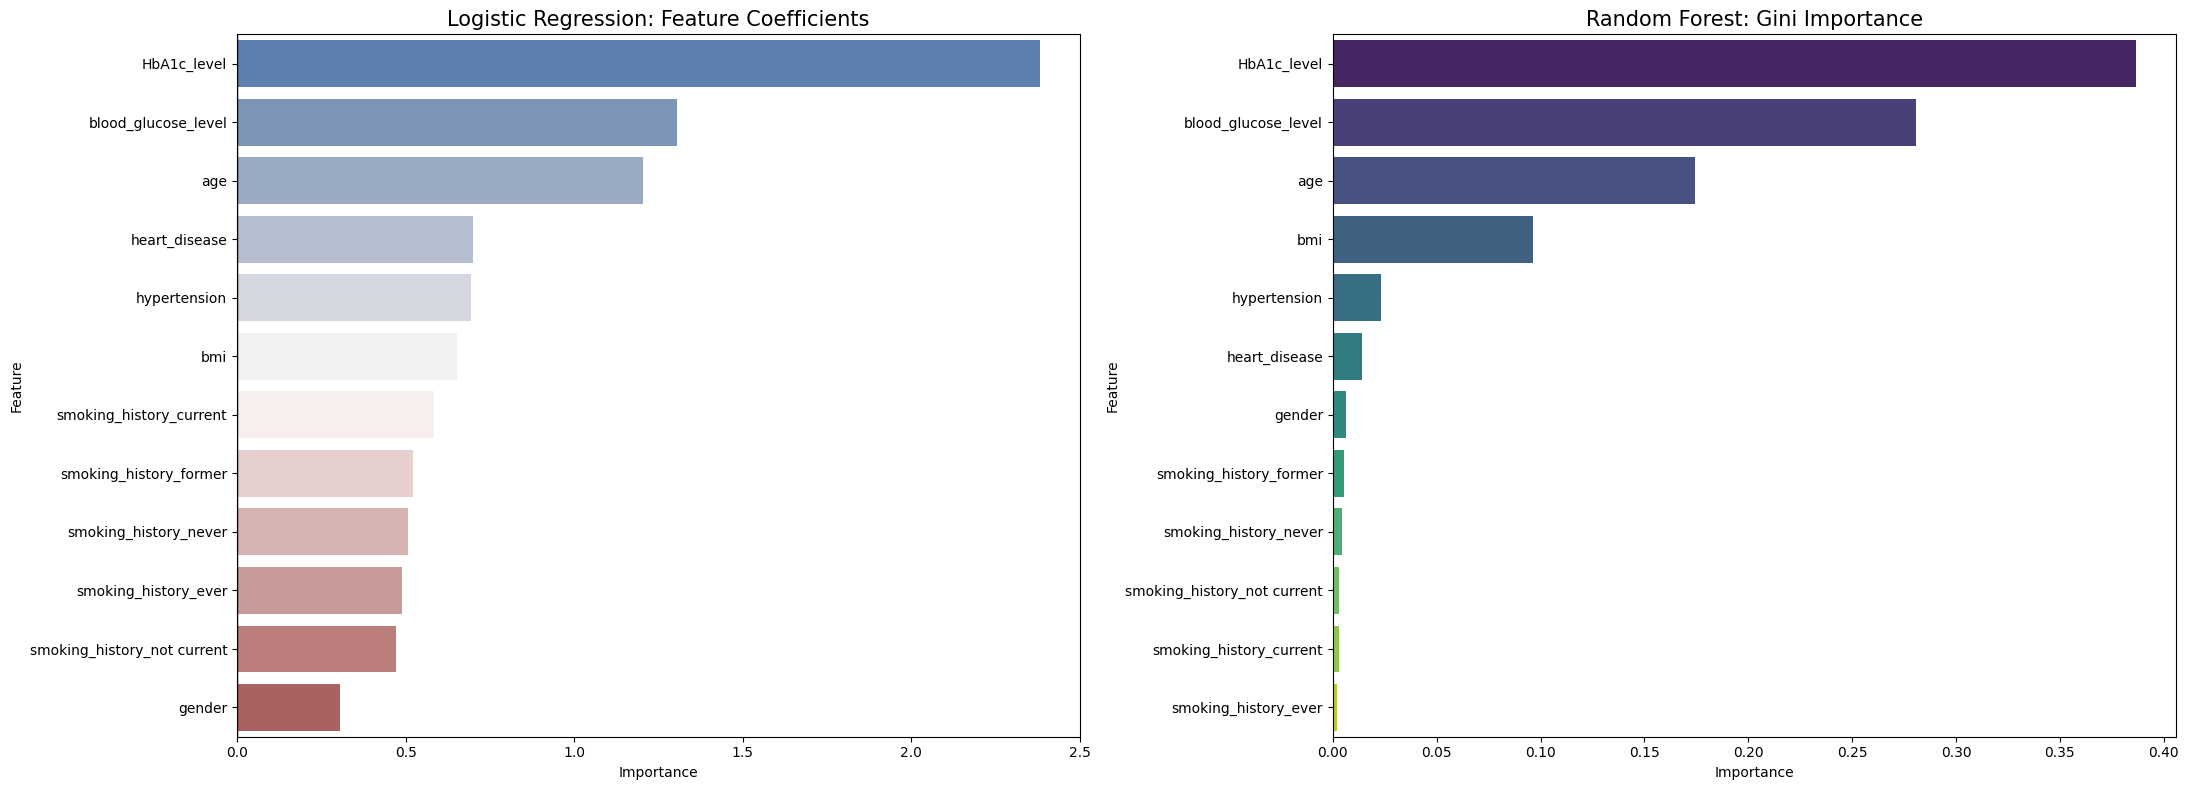

In [155]:
lgr_coefs = lgr_model.named_steps['classifier'].coef_[0]
lgr_names = lgr_model.named_steps['preprocessor'].get_feature_names_out()
df_lgr = pd.DataFrame({'Feature': lgr_names, 'Importance': lgr_coefs}).sort_values(by='Importance', ascending=False)
rf_importances = rfc_model.named_steps['classifier'].feature_importances_
rf_names = rfc_model.named_steps['preprocessor'].get_feature_names_out()
df_rf = pd.DataFrame({'Feature': rf_names, 'Importance': rf_importances}).sort_values(by='Importance', ascending=False)

df_rf['Feature'] = df_rf['Feature'].str.split('__').str[-1]
df_lgr['Feature'] = df_lgr['Feature'].str.split('__').str[-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (22, 8))
sns.barplot(data = df_lgr, x='Importance',
            y = 'Feature',
            ax = ax1,
            palette='vlag')
ax1.set_title("Logistic Regression: Feature Coefficients", fontsize=15)
ax1.axvline(0, color='black', lw=1)

sns.barplot(data = df_rf,
            x = 'Importance',
            y = 'Feature',
            ax = ax2,
            palette = 'viridis')
ax2.set_title("Random Forest: Gini Importance", fontsize=15)
plt.tight_layout()
plt.show()